# Capstone Assignment 20.1: Initial Report and Exploratory Data Analysis

**Overview**: This notebook provides exploratory data analysis and a baseline model on the [Real / Fake Job Posting Prediction Dataset](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction), making use of the article accompanying the dataset [here](https://www.icsd.aegean.gr/publication_files/290421648.pdf)



### Section 1: Understanding the Data

Before modeling, we confirm:
- the prediction target (binary classification),
- feature types (numeric vs categorical),
- missing values
- class imbalance 

### Section 2: Reading the Data

Use pandas to read in the dataset `fake_job_postings.csv` and assign to a meaningful variable name.

In [136]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import os

import re
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, RandomizedSearchCV 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MaxAbsScaler
from sklearn.inspection import permutation_importance
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, ComplementNB 
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

from wordcloud import WordCloud


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score,
    precision_recall_curve, auc, ConfusionMatrixDisplay, RocCurveDisplay,
)

RANDOM_STATE=42

#### Helper Functions

In [75]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'na_count': df.isna().sum(),
    'na_percentage': (df.isna().sum() / len(df)) * 100,
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.dropna().sample().iloc[0]
  })

In [76]:
def parse_salary_range(salary_str):
    """Parse salary range string and return min, max, and validity flag"""
    if pd.isna(salary_str) or salary_str == 'nan':
        return np.nan, np.nan, 'missing'
    
    salary_str = str(salary_str).replace(',', '').replace(' ', '')
    
    if salary_str == '0-0':
        return 0, 0, 'zero_range'
    
    if re.match(r'^\w+-\w+$', salary_str) and any(month in salary_str for month in ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']):
        return np.nan, np.nan, 'date_error'
    
    if '-' not in salary_str:
        try:
            val = float(salary_str)
            return val, val, 'single_value'
        except:
            return np.nan, np.nan, 'parse_error'
    
    try:
        parts = salary_str.split('-')
        if len(parts) == 2:
            min_sal = float(parts[0])
            max_sal = float(parts[1])
            
            # Check for reversed ranges
            if min_sal > max_sal:
                return max_sal, min_sal, 'reversed_range'
            
            # Check for unrealistic ranges
            if max_sal > 1e9:  # More than 1 billion
                return min_sal, max_sal, 'unrealistic_high'
            
            if max_sal < 100 and max_sal > 0:  # Likely hourly rate
                return min_sal, max_sal, 'likely_hourly'
            
            return min_sal, max_sal, 'valid'
        else:
            return np.nan, np.nan, 'parse_error'
    except:
        return np.nan, np.nan, 'parse_error'

In [77]:
def extract_country_from_location(location):
    """Extract country from location string"""
    if pd.isna(location):
        return 'Unknown'
    
    # Common patterns
    location = str(location).strip()
    
    # Check for country codes or full country names at the end
    parts = location.split(',')
    if len(parts) > 0:
        last_part = parts[-1].strip()
        
        # Map common country indicators
        country_map = {
            'US': 'USD', 'USA': 'USD', 'United States': 'USD',
            'UK': 'GBP', 'GB': 'GBP', 'United Kingdom': 'GBP',
            'CA': 'CAD', 'Canada': 'CAD',
            'AU': 'AUD', 'Australia': 'AUD',
            'IN': 'INR', 'India': 'INR',
            'DE': 'EUR', 'Germany': 'EUR',
            'FR': 'EUR', 'France': 'EUR',
            # Add more mappings as needed
        }
        
        return country_map.get(last_part, 'Unknown')
    
    return 'Unknown'

In [78]:
def detect_salary_outliers(df):
    """Detect salary outliers using IQR method"""
    Q1 = df['salary_mid_usd'].quantile(0.25)
    Q3 = df['salary_mid_usd'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[
        (df['salary_mid_usd'] < lower_bound) | 
        (df['salary_mid_usd'] > upper_bound)
    ]

In [111]:
def build_cv_row(name, out):
    """
    Build a summary row of cross-validated performance metrics for a single model.

    Aggregates the mean of each scoring metric returned by `sklearn.model_selection.cross_validate`,
    producing a flat dictionary suitable for appending to a results DataFrame.

    Parameters
    ----------
    name : str
        Display name of the ML model (e.g., "Logistic Regression", "Random Forest").

    out : dict
        Output dictionary returned by `sklearn.model_selection.cross_validate(...)`.
        Must have been called with `return_train_score=False` (default) and the
        following keys present under `scoring`:

        | Key                            | Metric                                      |
        |--------------------------------|---------------------------------------------|
        | ``test_accuracy``              | Overall accuracy                            |
        | ``test_precision``             | Precision for the minority (positive) class |
        | ``test_recall``                | Recall for the minority (positive) class    |
        | ``test_f1``                    | F1-score for the minority (positive) class  |
        | ``test_f1_weighted``           | Weighted F1-score across all classes        |
        | ``test_roc_auc``               | Area under the ROC curve                    |
        | ``test_precision_recall_auc``  | Area under the Precision-Recall curve       |
        | ``fit_time``                   | Time (seconds) to fit each fold             |
        | ``score_time``                 | Time (seconds) to score each fold           |

    Returns
    -------
    dict
        A flat dictionary with one value per metric (the cross-fold mean), plus the
        model name. Keys:

        - ``"model"``                 → `name`
        - ``"accuracy"``              → mean test accuracy
        - ``"precision"``             → mean minority-class precision
        - ``"recall"``                → mean minority-class recall
        - ``"f1"``                    → mean minority-class F1
        - ``"f1_weighted"``           → mean weighted F1
        - ``"roc_auc"``               → mean ROC-AUC
        - ``"precision_recall_auc"``  → mean PR-AUC
        - ``"Train Time (s)"``        → mean fit time per fold
        - ``"Test Time (s)"``         → mean score time per fold
    """
    return {
        "model": name,
        "accuracy":             out["test_accuracy"].mean(),
        "precision":            out["test_precision"].mean(),       # minority class
        "recall":               out["test_recall"].mean(),          # minority class
        "f1":                   out["test_f1"].mean(),              # minority class
        "f1_weighted":          out["test_f1_weighted"].mean(),
        "roc_auc":              out["test_roc_auc"].mean(),
        "precision_recall_auc": out["test_precision_recall_auc"].mean(),
        "Train Time (s)":       out["fit_time"].mean(),
        "Test Time (s)":        out["score_time"].mean()
    }



In [129]:
def visualize_metrics_graph(results_df, image_name):
    """
    Create comprehensive model comparison graph with performance metrics and timing.

    Parameters:
    - results_df: DataFrame with columns:
        ['model', 'accuracy', 'precision_recall_auc', 'recall', 'roc_auc',
         'Train Time (s)', 'Test Time (s)']
    - image_name: Name for saved image file
    """

    _, ax = plt.subplots(figsize=(16, 7))

    algorithms = results_df['model']
    x_pos = np.arange(len(algorithms))
    
    metric_names  = ['accuracy', 'precision_recall_auc', 'recall', 'roc_auc']
    metric_labels = ['Accuracy', 'PR-AUC', 'Recall', 'ROC-AUC']
    width         = 0.18                              # narrower — 4 bars still fit cleanly
    total_width   = width * len(metric_names)

    # ── Performance bars ─────────────────────────────────────────────────────
    for i, (metric, label) in enumerate(zip(metric_names, metric_labels)):
        values = results_df[metric].values
        bars   = ax.bar(
            x_pos + i * width, values, width,
            label=label,
            color=f'C{i}', alpha=0.82,
            edgecolor='white', linewidth=0.7
        )
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2.,
                bar.get_height() + 0.005,
                f'{value:.3f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold'
            )

    # ── Timing lines (log scale, right axis) ─────────────────────────────────
    ax2 = ax.twinx()
    ax2.set_yscale('log')

    center_offset = total_width / 2                   # centre timing lines on the bar group
    ax2.plot(
        x_pos + center_offset, results_df['Train Time (s)'],
        'ro-', label='Train Time (s)', linewidth=2.5, markersize=8
    )
    ax2.plot(
        x_pos + center_offset, results_df['Test Time (s)'],
        'gx--', label='Test Time (s)', linewidth=2.5, markersize=10, markeredgewidth=2
    )

    # ── Axes labels & limits ──────────────────────────────────────────────────
    ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance Score (0–1)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Time (s) — log scale', fontsize=12, fontweight='bold')

    ax.set_xticks(x_pos + center_offset)
    ax.set_xticklabels(algorithms, fontsize=11, rotation=45, ha='right')
    ax.set_ylim(0, 1.12)                              # extra headroom for value labels
    ax.set_title(
        'Holdout Set — Model Comparison: Performance vs. Computation Time',
        fontsize=13, fontweight='bold', pad=15
    )
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.set_axisbelow(True)

    # ── Combined legend ───────────────────────────────────────────────────────
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(
        lines1 + lines2, labels1 + labels2,
        loc='upper left', fontsize=10,
        frameon=True, fancybox=True, shadow=True
    )

    plt.tight_layout()
    plt.savefig(f'images/{image_name}_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [79]:
job_postings_df = pd.read_csv('data/fake_job_postings.csv')
print("Shape:", job_postings_df.shape)

Shape: (17880, 18)


In [80]:
job_postings_df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [81]:
job_postings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

### Observations

Given the column info and head samples, we can deduce the following:
- job_id is a unique ID which likely has little correlation to fraudulence
- salary range likely correlates to region/country. An unrealistic range -- too wide, or atypical to the job title - could correlate to fraudulency

### Section 3: Understanding the Features

Here, we examine the data, evaluating missingness, categorical vs text features.

In [82]:
job_postings_df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [83]:
data_quality_report(job_postings_df)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
job_id,int64,17880,0,0,0.000000,0.000000,17880,15725
title,object,17880,0,0,0.000000,0.000000,11231,Partnership Manager
location,object,17534,346,346,1.935123,1.935123,3105,"US, NY, New York City"
department,object,6333,11547,11547,64.580537,64.580537,1337,Strategic Initiatives
salary_range,object,2868,15012,15012,83.959732,83.959732,874,45000-50000
company_profile,object,14572,3308,3308,18.501119,18.501119,1709,The Financial Clinic was founded in 2005 to ad...
description,object,17879,1,1,0.005593,0.005593,14801,About the Position:The Partnership Manager ens...
requirements,object,15184,2696,2696,15.078300,15.078300,11967,Bachelor’s degreeCompetitive candidates will h...
benefits,object,10668,7212,7212,40.335570,40.335570,6204,Excellent benefit package that includes medica...
telecommuting,int64,17880,0,0,0.000000,0.000000,2,0


In [84]:
print(f"Total duplicated rows is {job_postings_df.duplicated().sum()}")

Total duplicated rows is 0


### Section 4: Most Missing Columns

Fraudulent postings often have more missing fields, e.g. no company logo, salary range, company profile.

fraudulent                  0         1
salary_range         0.844540  0.742494
company_profile      0.159927  0.677829
department           0.647467  0.613164
required_education   0.449865  0.520785
required_experience  0.388797  0.502309
benefits             0.402492  0.420323
function             0.359586  0.389145
industry             0.272011  0.317552
employment_type      0.189844  0.278291
requirements         0.149406  0.177829
location             0.019219  0.021940
description          0.000000  0.001155
job_id               0.000000  0.000000
telecommuting        0.000000  0.000000
has_questions        0.000000  0.000000
has_company_logo     0.000000  0.000000
title                0.000000  0.000000
fraudulent           0.000000  0.000000


/var/folders/zq/7j33ffkd46vd0yzyrk5qyj140000gn/T/ipykernel_59602/4154569629.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_class = job_postings_df.groupby('fraudulent').apply(


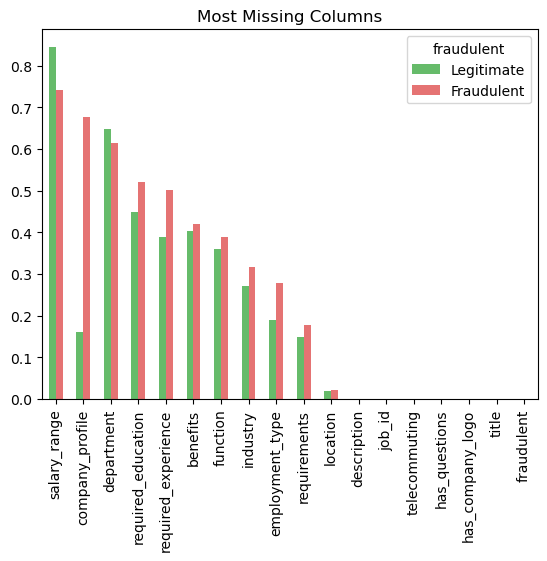

In [85]:
missing_by_class = job_postings_df.groupby('fraudulent').apply(
    lambda x: x.isnull().mean()
).T.sort_values(by=1, ascending=False)
print(missing_by_class)

##     ct.plot(kind='bar', color=['#E57373', '#66BB6A'], width=0.8, ax=axes[idx])
missing_plot = missing_by_class.plot(kind='bar', color=['#66BB6A', '#E57373'], legend=['Legitimate', 'Fraudulent'], title="Most Missing Columns")
legend = missing_plot.get_legend()

for text, label in zip(legend.get_texts(), ['Legitimate', 'Fraudulent']):
    text.set_text(label)

## Observations

Here, we can see that salary range has the most missing data, with company_profile, department, required_education closely trailing behind.

Here,  lack of a company profile could be a strong indicator of fraudulency.

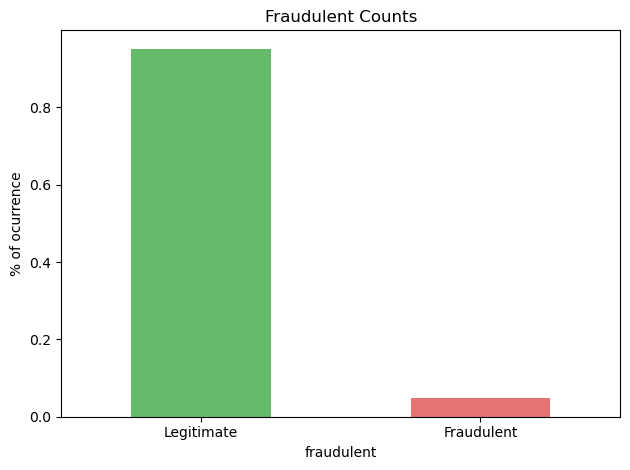

In [86]:
fraudulent_counts = job_postings_df['fraudulent'].value_counts(normalize=True)

fraudulent_counts.plot(title="Fraudulent Counts", kind="bar", color=['#66BB6A', '#E57373'])
plt.ylabel("% of ocurrence")
plt.xticks([0, 1], ["Legitimate", "Fraudulent"])
plt.tick_params(axis='x', rotation=0)
plt.savefig('images/fraudulent_counts.png')
plt.tight_layout()

### Section 5: Understanding the Task

**Business objective:** predict which job postings are fraudulent vs legitimate, so applicants can avoid providing PPI to scammers.

**ML objective:** learn a mapping from customer features to a binary response label and evaluate competing classifiers using cross-valdiation and a held-out test set.

### Section 6: Understanding and Visualizing Features

The following columns:
- description
- company_profile
- requirements
- benefits

are text columns suited for NLP feature engineering.

In [87]:
text_columns = ['description', 'company_profile', 'requirements', 'benefits'] 

In [88]:
num_cols = [col for col in job_postings_df.select_dtypes(include=[np.number]).columns.tolist() if col != "job_id"]
cat_cols = [col for col in job_postings_df.select_dtypes(include='object').columns.tolist() if col not in text_columns]

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

Numeric features: ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
Categorical features: ['title', 'location', 'department', 'salary_range', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']


In [89]:
for col in cat_cols + text_columns:
    job_postings_df[col] = job_postings_df[col].fillna(f"unknown {col} value")

data_quality_report(job_postings_df)

,data_type,non_null_count,null_count,na_count,na_percentage,null_percentage,unique_values,sample_value
job_id,int64,17880,0,0,0.0,0.0,17880,11026
title,object,17880,0,0,0.0,0.0,11231,Customer Service Manager (Consignor Relations)
location,object,17880,0,0,0.0,0.0,3106,"US, NJ, Secaucus"
department,object,17880,0,0,0.0,0.0,1338,Customer Service
salary_range,object,17880,0,0,0.0,0.0,875,unknown salary_range value
company_profile,object,17880,0,0,0.0,0.0,1710,The RealReal is changing the way people buy an...
description,object,17880,0,0,0.0,0.0,14802,The RealReal is the country’s largest online l...
requirements,object,17880,0,0,0.0,0.0,11968,unknown requirements value
benefits,object,17880,0,0,0.0,0.0,6205,unknown benefits value
telecommuting,int64,17880,0,0,0.0,0.0,2,0


### Understanding Numerical Correlations

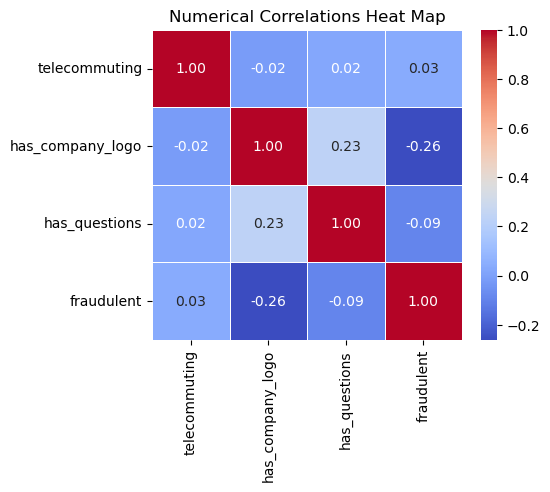

In [90]:
corr_matrix = job_postings_df[num_cols].corr()
n = len(corr_matrix.columns)

fig, ax = plt.subplots(figsize=(n * 1.4, n * 1.2))

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', linewidth=0.4, linecolor='white', square=True)
plt.savefig('images/numerical_correlations_heatmap.png')
plt.title("Numerical Correlations Heat Map")
plt.tight_layout()

#### Observations

Of the four numerical columns, `has_questions` and `has_company_logo` skew a job posting towards legitimate. Only `telecommuting` displays a positive correlation to fraudulency at `0.02`.

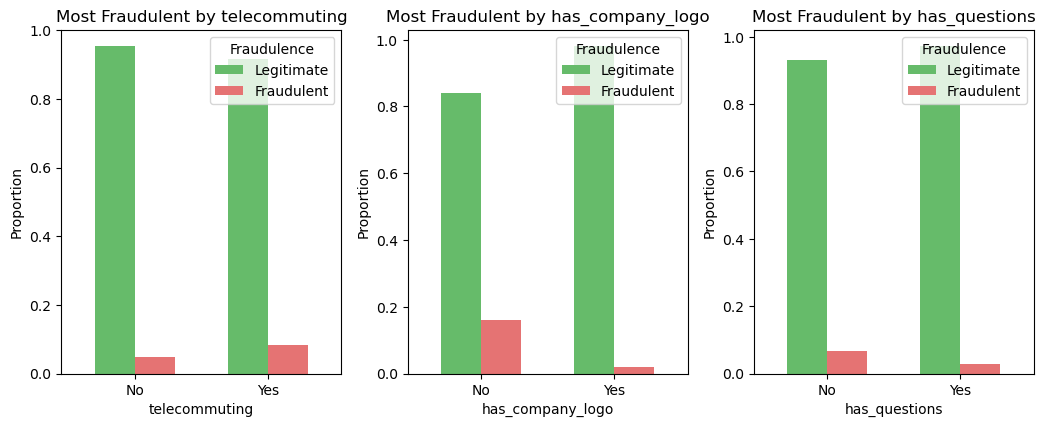

In [91]:
num_to_plot = [c for c in num_cols if c not in ['job_id', 'fraudulent'] and not bool(re.search(r'_len', col))]

# Calculate rows and columns for better layout
n_plots = len(num_to_plot)
n_cols = 4  # or however many columns you want
n_rows = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))

# This safely handles 1x1, 1D, and 2D arrays identically
axes = np.array(axes).flatten()

# Plot each distribution
for idx, col in enumerate(num_to_plot):
   
    ct = pd.crosstab(job_postings_df[col], job_postings_df['fraudulent'], normalize='index')
    
    # Stacked bar chart
    ct.plot(kind='bar', 
            ax=axes[idx], 
            color=['#66BB6A', '#E57373'],
            width=0.6)
    
    axes[idx].set_title(f"Most Fraudulent by {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Proportion")
    
    if job_postings_df[col].nunique() == 2:
        axes[idx].set_xticklabels(['No', 'Yes'], rotation=0)
    axes[idx].legend(['Legitimate', 'Fraudulent'], title='Fraudulence')

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('images/numerical_bar_plots.png')
plt.show()

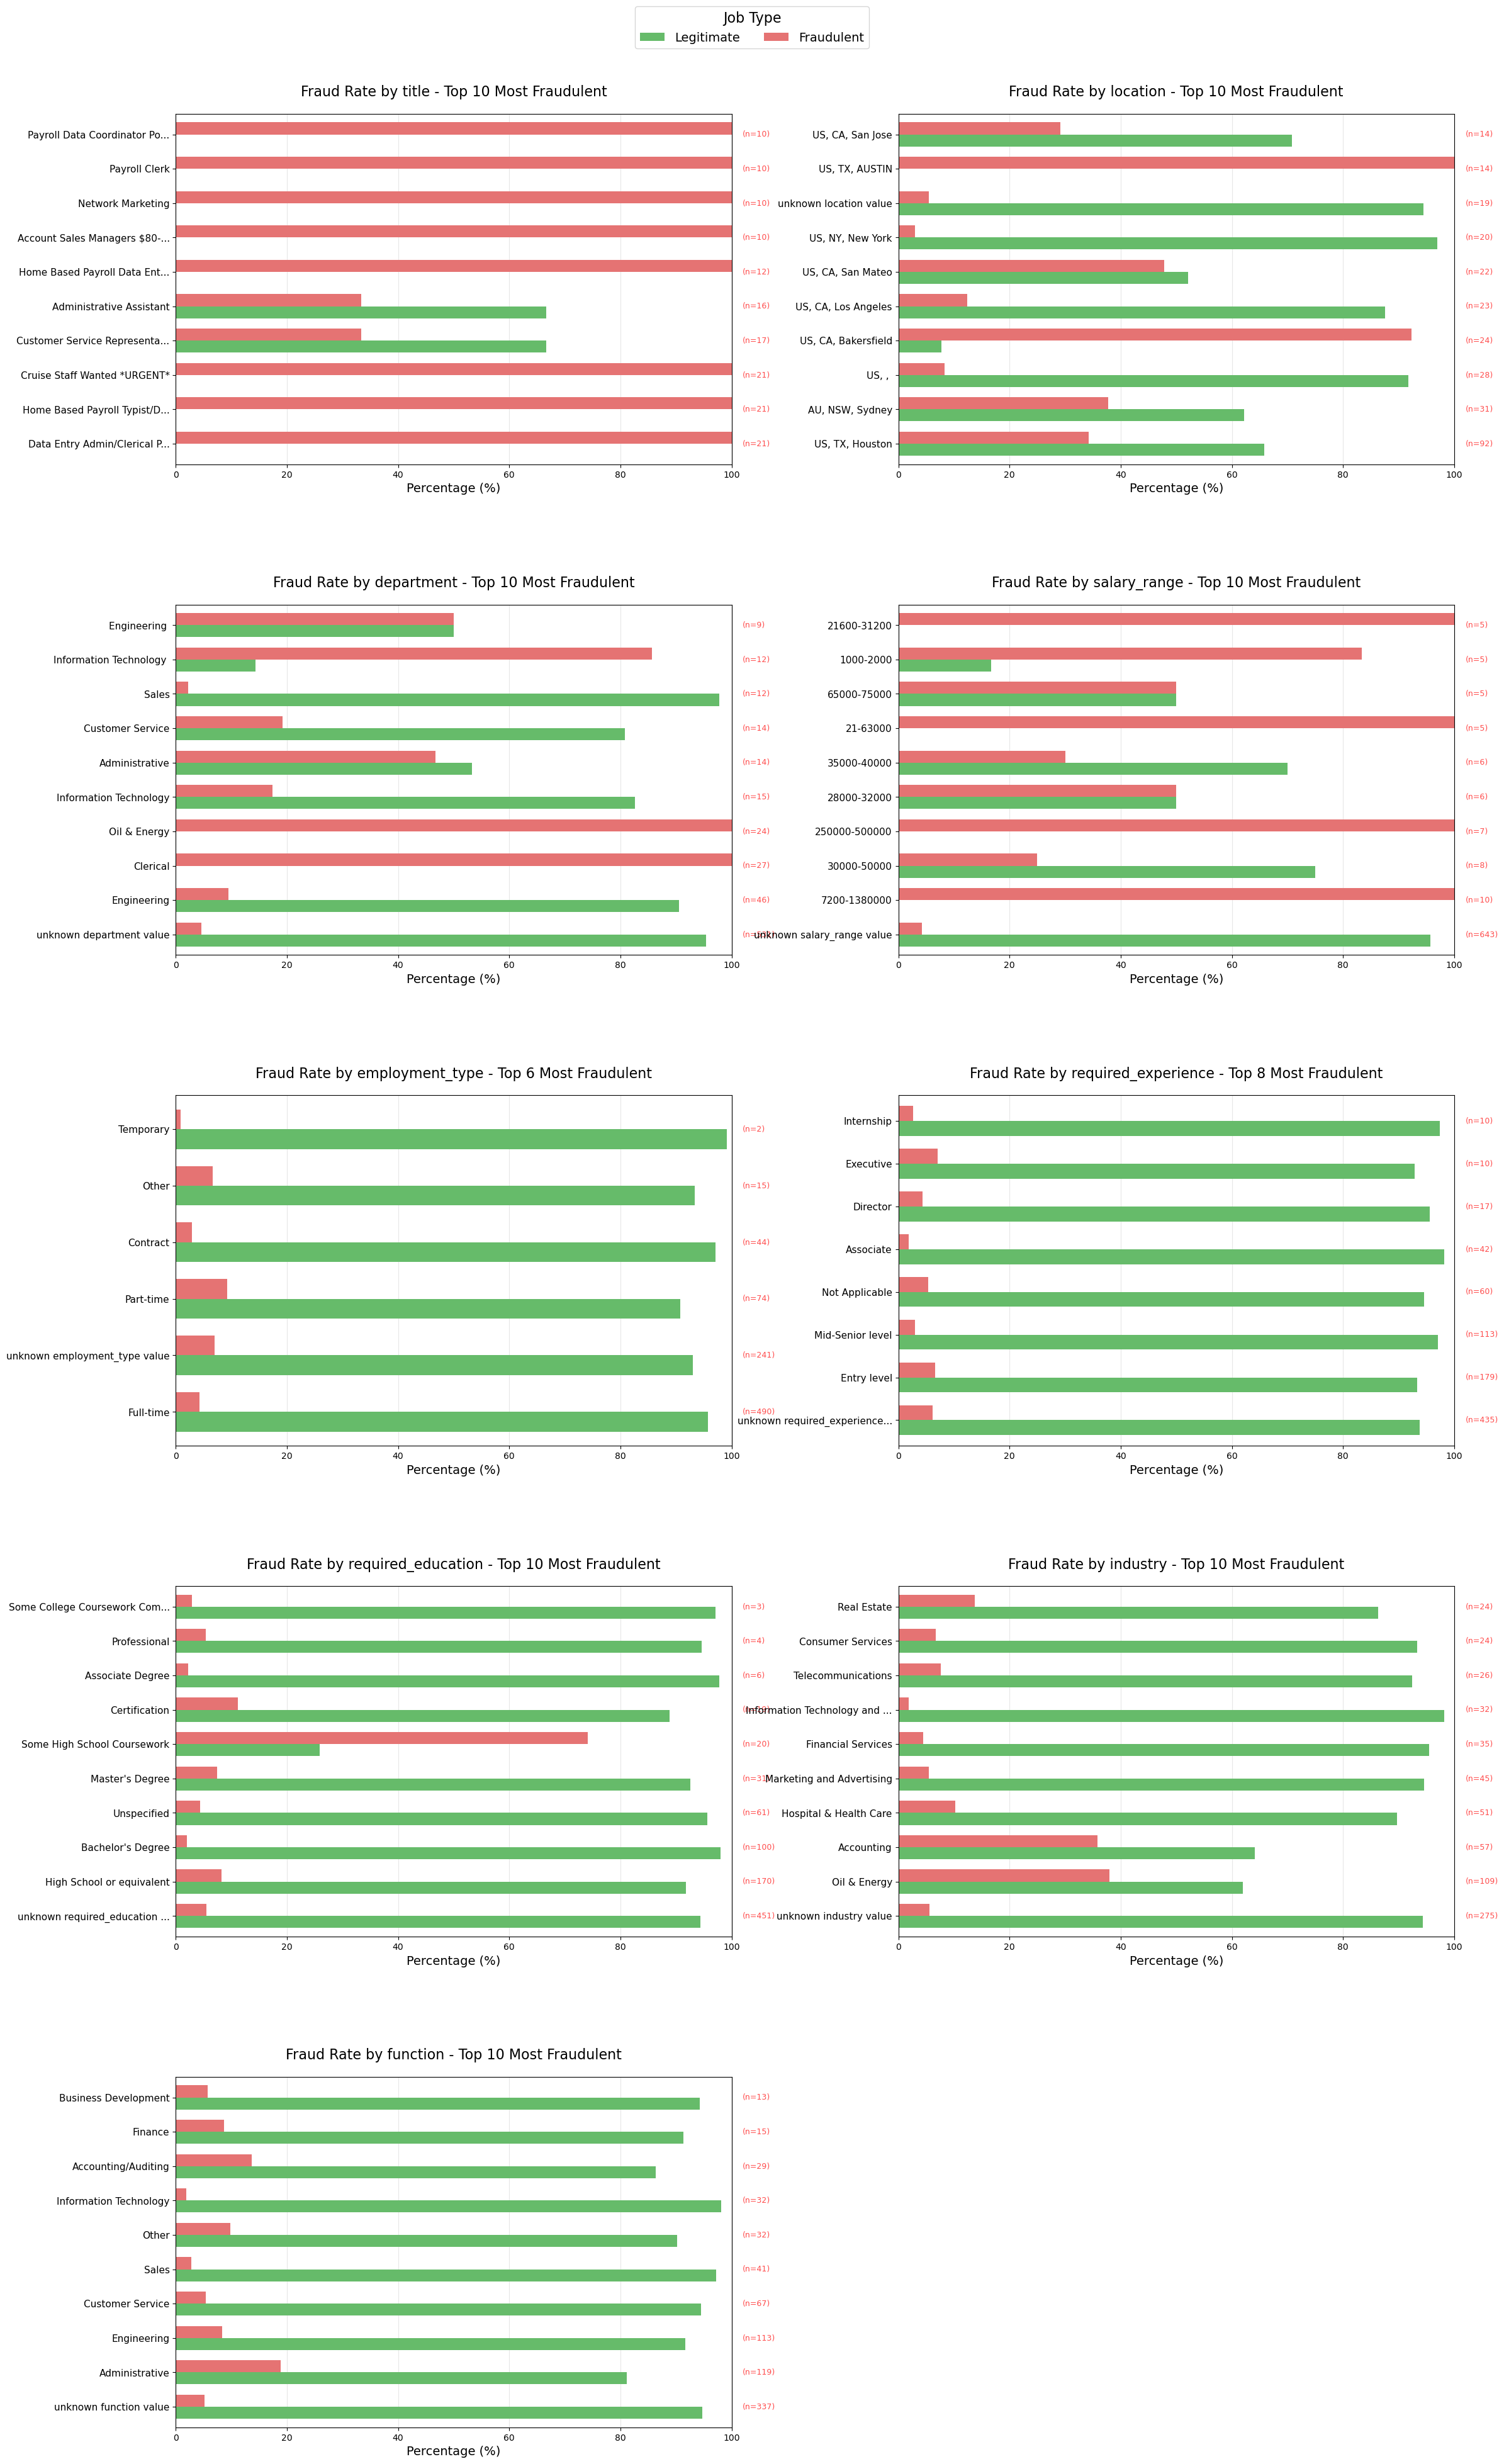

In [92]:
cat_to_plot = [c for c in cat_cols if c not in ['fraudulent'] + text_columns]

# Calculate rows and columns for better layout
n_plots = len(cat_to_plot)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

# Create figure with even larger size for horizontal bars
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
axes = axes.flatten() if n_plots > 1 else [axes]

# Plot each categorical variable
for idx, col in enumerate(cat_to_plot):
    # Get categories with highest fraud counts (fraudulent == 1)
    fraud_counts = job_postings_df[job_postings_df['fraudulent'] == 1][col].value_counts().head(10)
    top_fraud_categories = fraud_counts.index
    
    # Filter data to only include top fraudulent categories
    filtered_data = job_postings_df[job_postings_df[col].isin(top_fraud_categories)]
    
    # Create crosstab with percentages for filtered data
    ct = pd.crosstab(filtered_data[col], filtered_data['fraudulent'], normalize='index') * 100
    
    # Reorder by fraud count (most fraudulent first)
    ct = ct.reindex(top_fraud_categories)
    
    # Create horizontal bar plot
    ct.plot(kind='barh', 
            color=['#66BB6A', '#E57373'],
            width=0.7, 
            ax=axes[idx])
    
    # Set title and labels
    axes[idx].set_title(f"Fraud Rate by {col} - Top {len(top_fraud_categories)} Most Fraudulent", fontsize=16, pad=20)
    axes[idx].set_xlabel("Percentage (%)", fontsize=14)
    axes[idx].set_ylabel("", fontsize=12)
    
    # Remove individual legends
    if axes[idx].get_legend():
        axes[idx].get_legend().remove()
    
    labels = axes[idx].get_yticklabels()
    processed_labels = []
    for label in labels:
        text = label.get_text()
        
        # Then truncate if still too long
        if len(text) > 30:
            text = text[:27] + "..."
        
        processed_labels.append(text)
    
    axes[idx].set_yticklabels(processed_labels, fontsize=11)
    
    # Set x-axis limits for consistency
    axes[idx].set_xlim(0, 100)
    
    # Add grid for better readability
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].set_axisbelow(True)
    
    # Add fraud count annotation to the right of each bar
    for i, (category, count) in enumerate(fraud_counts.items()):
        axes[idx].text(102, i, f'(n={count})', 
                      va='center', fontsize=9, color='red', alpha=0.7)

# Hide unused subplots
for idx in range(len(cat_to_plot), len(axes)):
    axes[idx].set_visible(False)

# Add a single shared legend at the top of the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, 
    ['Legitimate', 'Fraudulent'], 
           title='Job Type',
           loc='upper center', 
           bbox_to_anchor=(0.5, 0.98),
           ncol=2, 
           fontsize=14,
           title_fontsize=16)

# Adjust layout with more spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.title("Top Fraudulent Categorical Values")
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.savefig('images/top_fraudulent_categories.png')
plt.show()

### Feature Extraction

Since the text and word lengths can differ between legitimate and fraudulent job postings, extract these lengths into numerical features.

In [93]:
for col in text_columns:
  job_postings_df[col + "_len"] = job_postings_df[col].str.len()
  job_postings_df[col + "_wc"] = job_postings_df[col].str.split().str.len()


### Text Fields

For text fields, we can see what type of words are frequent in fraudulent and legitimate jobs using wordclouds.

In the below code block, text fields are combined into one single column 

In [94]:
job_postings_df['text'] = job_postings_df[text_columns].fillna('').agg(
    lambda x: ' | '.join(filter(None, x)), axis=1
)

job_postings_clean = job_postings_df.drop(columns=text_columns)

job_postings_clean.shape

(17880, 23)

In [95]:
fraudulent_text = job_postings_clean[job_postings_clean['fraudulent'] == 1]['text']
legitimate_text = job_postings_clean[job_postings_clean['fraudulent'] == 0]['text']

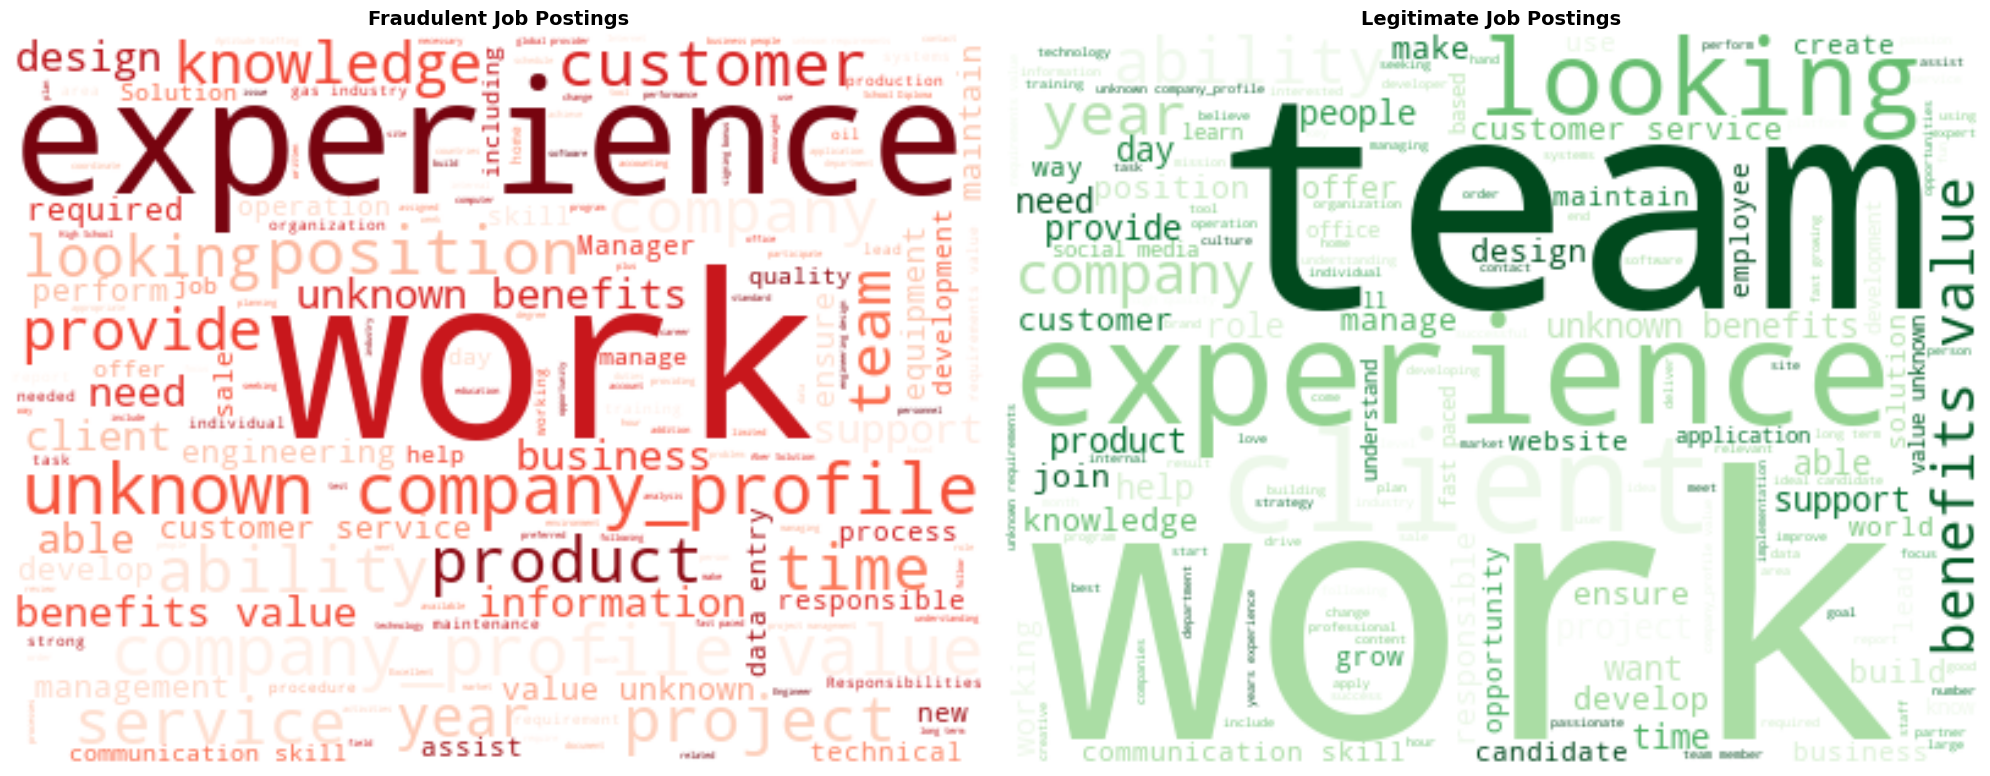

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Fraudulent wordcloud
fraudulent_wc = WordCloud(
    stopwords=ENGLISH_STOP_WORDS, width=400, height=300, 
    background_color='white', colormap='Reds'
).generate(' '.join(fraudulent_text))

ax1.imshow(fraudulent_wc, interpolation='bilinear')
ax1.set_title('Fraudulent Job Postings', fontsize=14, fontweight='bold')
ax1.axis('off')

# Legitimate wordcloud  
legitimate_wc = WordCloud(
    stopwords=ENGLISH_STOP_WORDS, width=400, height=300,
    background_color='white', colormap='Greens'
).generate(' '.join(legitimate_text))

ax2.imshow(legitimate_wc, interpolation='bilinear')
ax2.set_title('Legitimate Job Postings', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


### Section 7: Anomaly & Outlier Detection

As the rubric includes a section for analyzing outliers and anomalies, we analyze any outliers within salary range, which is 83% null.

In [97]:
job_postings_outliers_df = job_postings_clean.copy()

In [98]:
# Apply parsing
job_postings_outliers_df['salary_min'], job_postings_outliers_df['salary_max'], job_postings_outliers_df['salary_status'] = zip(*job_postings_outliers_df['salary_range'].apply(parse_salary_range))
job_postings_outliers_df['salary_mid'] = (job_postings_outliers_df['salary_min'] + job_postings_outliers_df['salary_max']) / 2
job_postings_outliers_df['salary_spread'] = job_postings_outliers_df['salary_max'] - job_postings_outliers_df['salary_min']

job_postings_outliers_df[['salary_min', 'salary_mid', 'salary_spread']].dropna()

,salary_min,salary_mid,salary_spread
6,20000.0,24000.0,8000.0
10,100000.0,110000.0,20000.0
15,120000.0,135000.0,30000.0
23,100000.0,110000.0,20000.0
31,50000.0,57500.0,15000.0
...,...,...,...
17844,0.0,0.0,0.0
17849,80000.0,90000.0,20000.0
17865,18000.0,19000.0,2000.0
17867,18000.0,18500.0,1000.0


In [99]:
# Extract country/currency
job_postings_outliers_df['currency'] = job_postings_outliers_df['location'].apply(extract_country_from_location)

# Currency conversion factors (approximate)
currency_to_usd = {
    'USD': 1.0,
    'GBP': 1.34,
    'EUR': 1.15,
    'CAD': 0.73,
    'AUD': 0.70,
    'INR': 0.012,
    'Unknown': 1.0  # Default to USD
}

# Normalize salaries to USD
job_postings_outliers_df['salary_min_usd'] = job_postings_outliers_df.apply(lambda x: x['salary_min'] * currency_to_usd.get(x['currency'], 1.0) 
            if pd.notna(x['salary_min']) else np.nan, axis=1)

job_postings_outliers_df['salary_mid_usd'] = job_postings_outliers_df.apply(lambda x: x['salary_mid'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_mid']) else np.nan, axis=1)
job_postings_outliers_df['salary_max_usd'] = job_postings_outliers_df.apply(lambda x: x['salary_max'] * currency_to_usd.get(x['currency'], 1.0) 
                                 if pd.notna(x['salary_max']) else np.nan, axis=1)

job_postings_outliers_df[['salary_min_usd', 'salary_mid_usd', 'salary_max_usd']].dropna()

,salary_min_usd,salary_mid_usd,salary_max_usd
6,20000.0,24000.0,28000.0
10,100000.0,110000.0,120000.0
15,120000.0,135000.0,150000.0
23,100000.0,110000.0,120000.0
31,50000.0,57500.0,65000.0
...,...,...,...
17844,0.0,0.0,0.0
17849,80000.0,90000.0,100000.0
17865,18000.0,19000.0,20000.0
17867,18000.0,18500.0,19000.0


In [100]:
salary_outliers_df = detect_salary_outliers(job_postings_outliers_df.dropna())
salary_outliers_df[salary_outliers_df['fraudulent'] == 1]

,job_id,title,location,department,salary_range,telecommuting,has_company_logo,has_questions,employment_type,required_experience,...,text,salary_min,salary_max,salary_status,salary_mid,salary_spread,currency,salary_min_usd,salary_mid_usd,salary_max_usd
5073,5074,Junior Engineer/Engineering Technician,"US, CA, San Jose","Engineering, Pipeline Design",6266624-8582080,0,0,1,Full-time,Entry level,...,"Founded in 1866, San Jose Water Company is an...",6266624.0,8582080.0,valid,7424352.0,2315456.0,Unknown,6266624.0,7424352.0,8582080.0
5687,5688,Network Marketing,"US, TX,",unknown department value,7200-1380000,0,0,0,Full-time,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
5691,5692,Network Marketing,"US, DE,",unknown department value,7200-1380000,0,0,0,Other,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
6056,6057,Payroll Data Entry Clerk Position - Earn $100...,"US, PA, Aaronsburg",Clerical,250000-500000,1,0,0,Full-time,Not Applicable,...,This job requires you to have the ability to o...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,375000.0,500000.0
6057,6058,Payroll Data Entry Clerk Position - Earn $100...,"GB, ABD, Ackerman",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,This job requires you to have the ability to o...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,375000.0,500000.0
6058,6059,Payroll Data Entry Clerk Position - Earn $100...,"GB, ABD,",Clerical,250000-500000,0,0,0,Full-time,Not Applicable,...,This job requires you to have the ability to o...,250000.0,500000.0,valid,375000.0,250000.0,Unknown,250000.0,375000.0,500000.0
6846,6847,Network Marketing,"US, MD,",unknown department value,7200-1380000,0,0,0,Full-time,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
6851,6852,Network Marketing,"US, FL,",unknown department value,7200-1380000,0,0,0,Full-time,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
6854,6855,Network Marketing,"US, AK,",unknown department value,7200-1380000,0,0,0,Other,Not Applicable,...,"Are you looking to make anywhere from 600-115,...",7200.0,1380000.0,valid,693600.0,1372800.0,Unknown,7200.0,693600.0,1380000.0
8722,8723,Hiring for Business Intelligence and Analytic...,"US, WA, Bellevue",unknown department value,140000-160000,0,0,0,Full-time,Mid-Senior level,...,"Position :Manager, Software DevelopmentJob Typ...",140000.0,160000.0,valid,150000.0,20000.0,Unknown,140000.0,150000.0,160000.0


While we explored salary range outliers via standardization of currencies to USD, only 8 rows are fraudulent, so salary_range can be dropped from training features.

## Section 8: Create Numerical, Categorical, TFIDF Features

In [101]:
# ── Apply feature engineering to full dataframe ───────────────────────────────
salary_parsed = job_postings_clean['salary_range'].apply(
    lambda x: pd.Series(parse_salary_range(x), index=['salary_min', 'salary_max', 'salary_validity'])
)

job_postings_clean = pd.concat([job_postings_clean, salary_parsed], axis=1)
job_postings_clean['salary_range_width'] = (
    job_postings_clean['salary_max'] - job_postings_clean['salary_min']
)
job_postings_clean['location_country'] = job_postings_clean['location'].apply(
    extract_country_from_location
)

In [102]:
num_features = [col for col in job_postings_clean.columns if bool(re.search(r'_(len|wc)$', col))]

num_features_tree = num_features + ['salary_min', 'salary_max', 'salary_range_width']

In [103]:
cat_features = ['department', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']

cat_features_tree = cat_features+ ['location_country', 'salary_validity']

In [104]:
numeric_transformer = Pipeline([
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
  ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

tfidf_title = Pipeline([
  ('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))
])

tfidf_text = Pipeline([
  ('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))
])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features),
    ('tfidf_title', tfidf_title, 'title'),
    ('tfidf_text', tfidf_text, 'text')
  ],
  remainder='drop'
)

### Dropping Columns

The following columns are dropped from feature selection:
- job_id, unique ID for each job application
- salary related features. With 86% missing and roughy equivalent percentages of legitimate and fraudulent counts, likely little impact on predictions.

### Section 9: Train/Test Split

With your data prepared, split it into a train and test set.

In [105]:
job_postings_sans_salary_location = job_postings_clean.loc[:, ~job_postings_clean.columns.str.contains("salary|location|currency", case=False, regex=True)]

X = job_postings_sans_salary_location.drop(columns=['job_id', 'salary_range', 'fraudulent'], errors='ignore')
X_tree = job_postings_clean.drop(columns=['job_id', 'salary_range', 'fraudulent', 'location'])
y = job_postings_clean['fraudulent']

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=RANDOM_STATE)

X_tree_train, X_tree_test, _, _ = train_test_split(
    X_tree, y, train_size=0.8, random_state=RANDOM_STATE, stratify=y
)

display(y_train.value_counts(dropna=False) / len(y_train))
display(y_test.value_counts(dropna=False)/len(y_test))

fraudulent
0    0.951552
1    0.048448
Name: count, dtype: float64

fraudulent
0    0.951622
1    0.048378
Name: count, dtype: float64

In [119]:
# ── X routing per model ───────────────────────────────────────────────────────
def get_X_for_model(name, split="Train"):
    if name in ["XGBoost"]:                 # both use tree preprocessor
        return X_tree_train if split.lower() == "train" else X_tree_test
    return X_train if split.lower() == "train" else X_test

### Section 10: A Baseline Model

Use Logistic Regression to build a basic model on your data.  

In [133]:
baseline_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
start_time = time.time()
baseline_rf.fit(X_train, y_train)

fit_time = time.time() - start_time
rf_preds = baseline_rf.predict(X_test)

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [134]:
f1 = f1_score(y_test, rf_preds)
pr_auc = average_precision_score(y_test, rf_preds)
roc_auc = roc_auc_score(y_test, rf_preds)
recall = recall_score(y_test, rf_preds)
print("F1 Score:", f1)
print("PR AUC Score:", pr_auc)
print("ROC AUC Score:", roc_auc)
print("Recall:", recall)
print(f"Fit time: {fit_time:.2f} seconds")

F1 Score: 0.6324110671936759
PR AUC Score: 0.48843445707413585
ROC AUC Score: 0.7312138728323699
Recall: 0.4624277456647399
Fit time: 8.53 seconds


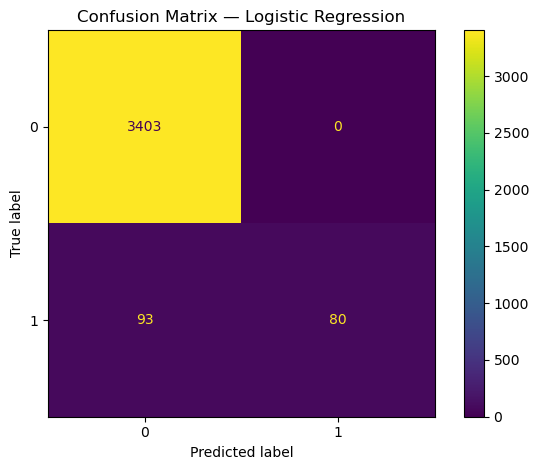

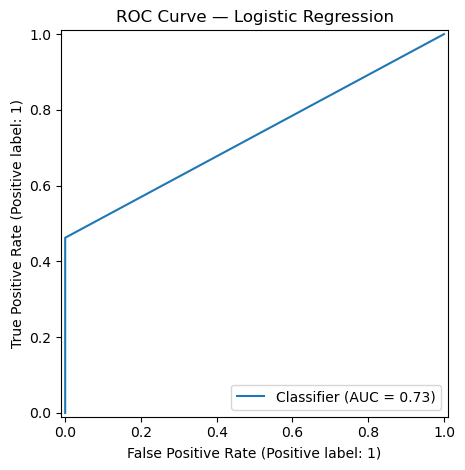

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, values_format="d")
plt.title(f"Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig('images/baseline_model_confusion_matrix.png')
plt.show()

RocCurveDisplay.from_predictions(y_test, rf_preds)
plt.title(f"ROC Curve — Random Forest")
plt.tight_layout()
plt.savefig('images/baseline_model_roc_auc_curve.png')
plt.show()

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, rf_preds)
auc_score = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Random Forest Baseline')
plt.legend()
plt.show()

### Section 11: Model Comparisons

Now, compare the performance of Logistic Regression model to other classification algorithms 

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), num_features),
        ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_features),
        ('tfidf_title', Pipeline([('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))]), 'title'),
        ('tfidf_text', Pipeline([('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))]), 'text')
    ],
    remainder='drop'
)

# ── Linear SVM preprocessor: high-dim TF-IDF ─────────────────────────────────
preprocessor_svm = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), num_features),
        ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_features),
        ('tfidf_title', Pipeline([('tfidf', TfidfVectorizer(max_features=3000, norm='l2', stop_words='english'))]), 'title'),  # higher dim
        ('tfidf_text', Pipeline([('tfidf', TfidfVectorizer(max_features=3000, norm='l2', stop_words='english'))]), 'text')    # higher dim
    ],
    remainder='drop'
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', StandardScaler())]), num_features_tree),
        ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_features_tree),
        ('tfidf_title', Pipeline([('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))]), 'title'),
        ('tfidf_text',  Pipeline([('tfidf', TfidfVectorizer(max_features=500, norm='l2', stop_words='english'))]), 'text')
    ],
    remainder='drop'
)

In [112]:
smote = SMOTE(random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'precision_recall_auc': 'average_precision',   
    'f1': 'f1',                                    
    'recall': 'recall',                            
    'precision': 'precision',                      
    'roc_auc': 'roc_auc',                          
    'f1_weighted': 'f1_weighted',                  
    'accuracy': 'accuracy',   
}
def run_cv(name: str, pipe, X, y, cv, scoring) -> dict:
    """Fit cross_validate with timing logs and return a cv_row dict."""
    print(f"Starting cross validation for {name}...")
    start = time.time()
    out = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"Finished {name} in {time.time() - start:.2f}s")
    return build_cv_row(name, out)


# ── Pipeline definitions ──────────────────────────────────────────────────────

svm_pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor_svm),
    ("smote", smote),
    ("model", CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE)))
])

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor_tree),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        max_features="sqrt",
        min_samples_leaf=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

mlp_pipe = ImbPipeline(steps=[
    ("preprocess", preprocessor_svm),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("model", MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=0.001,
        batch_size=256,
        learning_rate="adaptive",
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ))
])

# ── Cross validation runs ─────────────────────────────────────────────────────
#  (name, pipe, X) — y, cv, scoring are shared across all
experiments = [
    ("Linear SVM + SMOTE", svm_pipe, X_train),
    ("XGBoost",            xgb_pipe, X_tree_train),
    ("Random Forest",      rf_pipe,  X_train),
    ("MLP + SMOTE",        mlp_pipe, X_train),
]

cv_rows = [
    run_cv(name, pipe, X, y_train, cv, scoring)
    for name, pipe, X in experiments
]

# ── Results ───────────────────────────────────────────────────────────────────
holdout_df = (
    pd.DataFrame(cv_rows)
    .sort_values("precision_recall_auc", ascending=False)   # ← sort by primary scorer
    .reset_index(drop=True)
)
holdout_df

Starting cross validation for Linear SVM + SMOTE...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/pytho

Finished Linear SVM + SMOTE in 34.42s
Starting cross validation for XGBoost...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4, 7] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4, 6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/py

Finished XGBoost in 36.35s
Starting cross validation for Random Forest...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/

Finished Random Forest in 19.74s
Starting cross validation for MLP + SMOTE...


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.

Finished MLP + SMOTE in 102.93s


,model,accuracy,precision,recall,f1,f1_weighted,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,MLP + SMOTE,0.983920,0.897833,0.756032,0.819888,0.983267,0.984534,0.890669,95.669146,2.031197
1,Linear SVM + SMOTE,0.981963,0.919308,0.688343,0.786970,0.980716,0.980427,0.864939,21.107136,1.359099
2,XGBoost,0.973574,0.698164,0.806673,0.747890,0.974512,0.978804,0.854053,30.201445,1.920461
3,Random Forest,0.972735,0.964682,0.454530,0.616332,0.967962,0.985525,0.846138,12.302632,1.877524


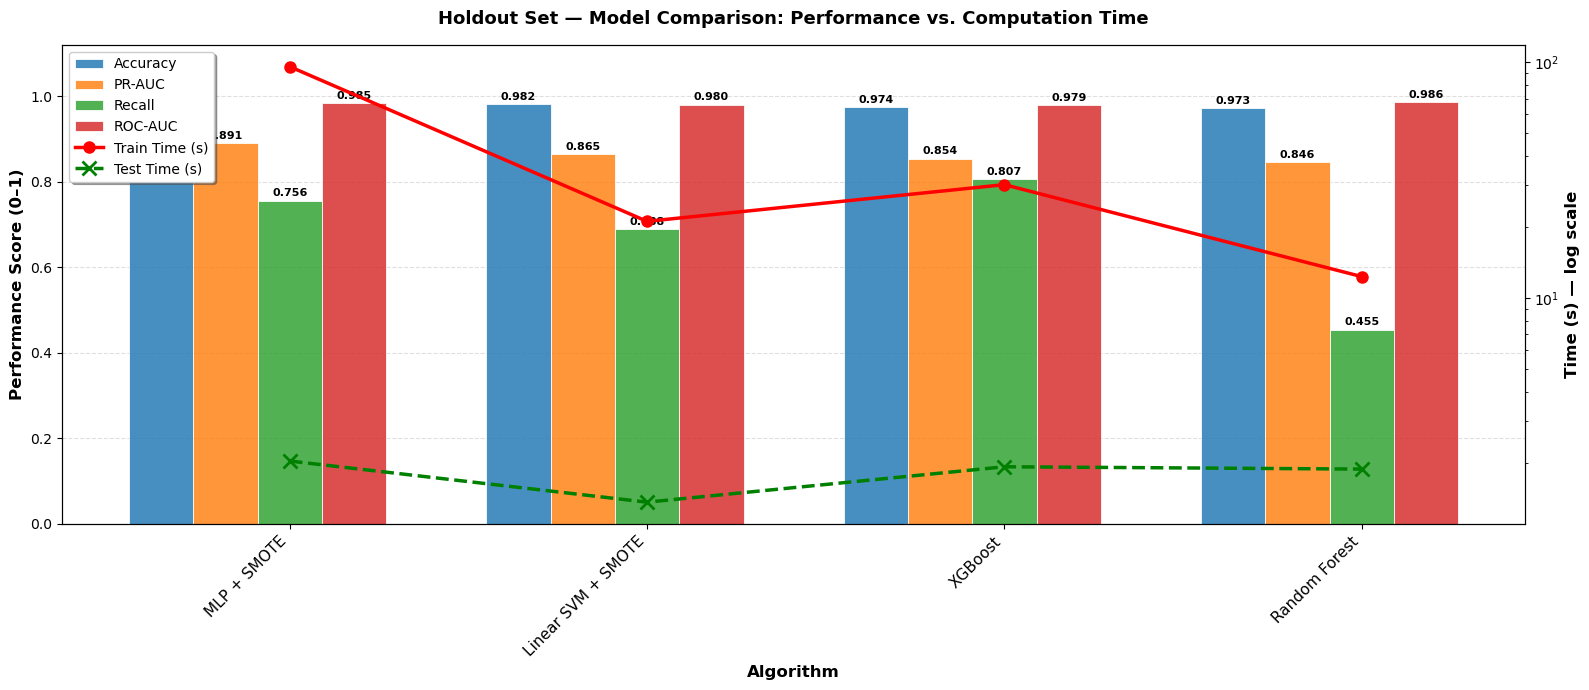

In [130]:
visualize_metrics_graph(holdout_df, 'holdout_models')

### Section 12: Improving the Model

Each model is tuned using GridSearchCV with F1 as the optimization metric.

In [ ]:
# ── Param distributions (RandomizedSearchCV-compatible) ───────────────────────
tuning_param_grids = {
    "MLP + SMOTE": {
        "model__hidden_layer_sizes": [
            (256, 128),
            (512, 256),
            (256, 128, 64),
            (512, 256, 128),
            (128, 64),
        ],
        "model__alpha": loguniform(1e-4, 1e-1),             # L2 regularisation strength
        "model__learning_rate_init": loguniform(1e-4, 1e-2),
        "model__batch_size": [128, 256, 512],
        "model__activation": ["relu", "tanh"],
    },
    "Linear SVM + SMOTE": {
        "model__estimator__C": [0.1, 0.5, 1.0, 5.0, 10.0], # estimator__ because of CalibratedClassifierCV wrapper
        "model__estimator__max_iter": [2000, 5000],
        "smote__k_neighbors": [3, 5, 7]                     # also tune SMOTE's neighborhood size
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [4, 6, 8],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__subsample": [0.8, 1.0],                     # row subsampling — reduces overfitting
        "model__colsample_bytree": [0.8, 1.0]               # feature subsampling per tree
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"]             # controls feature diversity per split
    },
}

# ── Pipeline builders per model ───────────────────────────────────────────────
def build_tuning_pipe(name, model):
    if name in ["Linear SVM + SMOTE", "MLP + SMOTE"]:
        return ImbPipeline(steps=[
            ("preprocess", preprocessor_svm),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model)
        ])
    elif name == "XGBoost":                                  # tree preprocessor for XGBoost
        return Pipeline(steps=[
            ("preprocess", preprocessor_tree),
            ("model", model)
        ])
    else:                                                    # Random Forest
        return Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ])



# ── Model instances (fresh, unfit) ───────────────────────────────────────────
tuning_model_instances = {
    "MLP + SMOTE": MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        learning_rate="adaptive",
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE
    ),
    "Linear SVM + SMOTE": CalibratedClassifierCV(
        LinearSVC(random_state=RANDOM_STATE)
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

# ── n_iter per model (controls search budget) ────────────────────────────────
tuning_n_iter = {
    "MLP + SMOTE": 15,          # expensive — keep low
    "Linear SVM + SMOTE": 20,   # small grid, can afford more
    "XGBoost": 20,
    "Random Forest": 20,
}

# ── Tuning loop ───────────────────────────────────────────────────────────────
if RUN_TUNING:
    best_models = {}
    tuning_rows = []

    for name, model in tuning_model_instances.items():
        print(f"\nPerforming randomized search for {name}")
        X_input = get_X_for_model(name)
        pipe = build_tuning_pipe(name, model)

        search = RandomizedSearchCV(
            pipe,
            param_distributions=tuning_param_grids[name],
            n_iter=tuning_n_iter[name],
            scoring="average_precision",
            cv=cv,
            n_jobs=1 if name == "MLP + SMOTE" else -1,          # MLP parallelism guard
            verbose=1,
            random_state=RANDOM_STATE,
            refit=True
        )

        search.fit(X_input, y_train)
        best_models[name] = search.best_estimator_

        tuning_rows.append({
            "model": f"Tuned {name}",
            "best_pr_auc_cv": search.best_score_,
            "best_params": search.best_params_,
            "train_time_s": search.cv_results_["mean_fit_time"].mean(),   
            "score_time_s": search.cv_results_["mean_score_time"].mean()
        })

    tuning_df = (
        pd.DataFrame(tuning_rows)
        .sort_values("best_pr_auc_cv", ascending=False)
        .reset_index(drop=True)
    )
    tuning_df.to_csv('data/tuned_models.csv', index=False)
    print("\n✅ Tuning complete — results saved to data/tuned_models.csv")
else:
    print("⏭️  RUN_TUNING=False — skipping tuning block.")

tuning_df

In [115]:
for _, row in tuning_df.iterrows():
    print(f"\n{'='*50}")
    print(f"Model: {row['model']}")
    print(f"Model fit time: {row['train_time_s']:.4f} seconds")
    print(f"Best PR AUC CV: {row['best_pr_auc_cv']:.4f}")
    print(f"Best Params:")
    for param, value in row['best_params'].items():
        print(f"  {param}: {value}")


Model: Tuned MLP + SMOTE
Model fit time: 79.0852 seconds
Best PR AUC CV: 0.8999
Best Params:
  model__activation: relu
  model__alpha: 0.00033120277014659456
  model__batch_size: 128
  model__hidden_layer_sizes: (512, 256, 128)
  model__learning_rate_init: 0.00023145798905204883

Model: Tuned XGBoost
Model fit time: 68.4809 seconds
Best PR AUC CV: 0.8849
Best Params:
  model__subsample: 0.8
  model__n_estimators: 500
  model__max_depth: 8
  model__learning_rate: 0.1
  model__colsample_bytree: 1.0

Model: Tuned Linear SVM + SMOTE
Model fit time: 38.4749 seconds
Best PR AUC CV: 0.8653
Best Params:
  smote__k_neighbors: 7
  model__estimator__max_iter: 2000
  model__estimator__C: 0.5

Model: Tuned Random Forest
Model fit time: 11.4964 seconds
Best PR AUC CV: 0.8553
Best Params:
  model__n_estimators: 500
  model__min_samples_split: 2
  model__min_samples_leaf: 1
  model__max_features: log2
  model__max_depth: None


In [116]:
tuning_df.to_csv('data/tuned_models.csv')

In [127]:
tuned_rf = best_models.get("Random Forest")

X_test_rf = X_tree_test   # Random Forest uses tree preprocessor — no get_X_for_model needed for test

# ── Predict on holdout set ────────────────────────────────────────────────────
rf_pred  = tuned_rf.predict(X_test_rf)
rf_proba = tuned_rf.predict_proba(X_test_rf)[:, 1]

# ── Compute metrics ───────────────────────────────────────────────────────────
accuracy_rf  = accuracy_score(y_test, rf_pred)
precision_rf = precision_score(y_test, rf_pred, zero_division=0)
recall_rf    = recall_score(y_test, rf_pred, zero_division=0)
f1_rf        = f1_score(y_test, rf_pred, zero_division=0, average='weighted')
roc_auc_rf   = roc_auc_score(y_test, rf_proba)
pr_auc_rf    = average_precision_score(y_test, rf_proba)

# ── Build summary row ─────────────────────────────────────────────────────────
tuned_rf_metrics = {
    "model":                "Tuned Random Forest",
    "accuracy":             accuracy_rf,
    "precision":            precision_rf,
    "recall":               recall_rf,
    "f1":                   f1_rf,
    "roc_auc":              roc_auc_rf,
    "precision_recall_auc": pr_auc_rf       # ← consistent with holdout_df column name
}
tuned_rf_df = pd.DataFrame([tuned_rf_metrics])

# ── Combine with holdout baseline results ─────────────────────────────────────
comparison_df = pd.concat(
    [holdout_df[holdout_df["model"] != "Random Forest"], tuned_rf_df],
    ignore_index=True
)

# ── Sort by PR-AUC — use the actual column name ───────────────────────────────
comparison_df = (
    comparison_df
    .sort_values(by="precision_recall_auc", ascending=False)   # ← was "pr_auc" (KeyError)
    .reset_index(drop=True)
)
display(comparison_df)

# ── Summary print ─────────────────────────────────────────────────────────────
print("\n--- Comparison Summary ---\n")
print(
    f"Tuned Random Forest — PR-AUC: {pr_auc_rf:.4f} | "
    f"F1: {f1_rf:.4f} | ROC-AUC: {roc_auc_rf:.4f}"
)

# ── CV vs holdout gap ─────────────────────────────────────────────────────────
if "tuning_df" in dir() and (tuning_df["model"] == "Tuned Random Forest").any():
    cv_pr_auc = tuning_df.loc[
        tuning_df["model"] == "Tuned Random Forest", "best_pr_auc_cv"
    ].iloc[0]
    print(
        f"CV PR-AUC (tuning): {cv_pr_auc:.4f}  →  Holdout PR-AUC: {pr_auc_rf:.4f}  "
        f"({'↑ generalises well' if pr_auc_rf >= cv_pr_auc else '↓ some overfitting'})"
    )

# ── Delta vs untuned baseline ─────────────────────────────────────────────────
if (holdout_df["model"] == "Random Forest").any():
    old_pr = holdout_df.loc[
        holdout_df["model"] == "Random Forest", "precision_recall_auc"   # ← was "pr_auc"
    ].iloc[0]
    print(
        f"Untuned Random Forest PR-AUC: {old_pr:.4f}  →  "
        f"Delta: {pr_auc_rf - old_pr:+.4f}"
    )

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,model,accuracy,precision,recall,f1,f1_weighted,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,MLP + SMOTE,0.983920,0.897833,0.756032,0.819888,0.983267,0.984534,0.890669,95.669146,2.031197
1,Tuned Random Forest,0.971756,1.000000,0.416185,0.966141,NaN,0.989017,0.889665,NaN,NaN
2,Linear SVM + SMOTE,0.981963,0.919308,0.688343,0.786970,0.980716,0.980427,0.864939,21.107136,1.359099
3,XGBoost,0.973574,0.698164,0.806673,0.747890,0.974512,0.978804,0.854053,30.201445,1.920461



--- Comparison Summary ---

Tuned Random Forest — PR-AUC: 0.8897 | F1: 0.9661 | ROC-AUC: 0.9890
CV PR-AUC (tuning): 0.8553  →  Holdout PR-AUC: 0.8897  (↑ generalises well)
Untuned Random Forest PR-AUC: 0.8461  →  Delta: +0.0435


In [122]:
test_rows = []

for name, est in best_models.items():
    X_input = get_X_for_model(name, split='test')   # mirrors tuning loop input routing
    pred = est.predict(X_input)
    proba = est.predict_proba(X_input)[:, 1]

    test_rows.append({
        "model": f"Tuned {name}",
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall":  recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
        "precision_recall_auc": average_precision_score(y_test, proba),
        "Train Time (s)": tuning_df.loc[tuning_df["model"] == f"Tuned {name}", "train_time_s"].values[0],
        "Test Time (s)": tuning_df.loc[tuning_df["model"] == f"Tuned {name}", "score_time_s"].values[0],
    })

test_df = (
    pd.DataFrame(test_rows)
    .sort_values("precision_recall_auc", ascending=False)
    .reset_index(drop=True)
)
test_df

/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/pytho

,model,accuracy,precision,recall,f1,roc_auc,precision_recall_auc,Train Time (s),Test Time (s)
0,Tuned MLP + SMOTE,0.986298,0.942857,0.763006,0.843450,0.990569,0.924920,79.085217,1.147567
1,Tuned XGBoost,0.987696,0.964029,0.774566,0.858974,0.989639,0.916947,68.480873,3.373547
2,Tuned Linear SVM + SMOTE,0.984060,0.908451,0.745665,0.819048,0.987242,0.911491,38.474898,2.555615
3,Tuned Random Forest,0.971756,1.000000,0.416185,0.587755,0.989017,0.889665,11.496365,1.881949


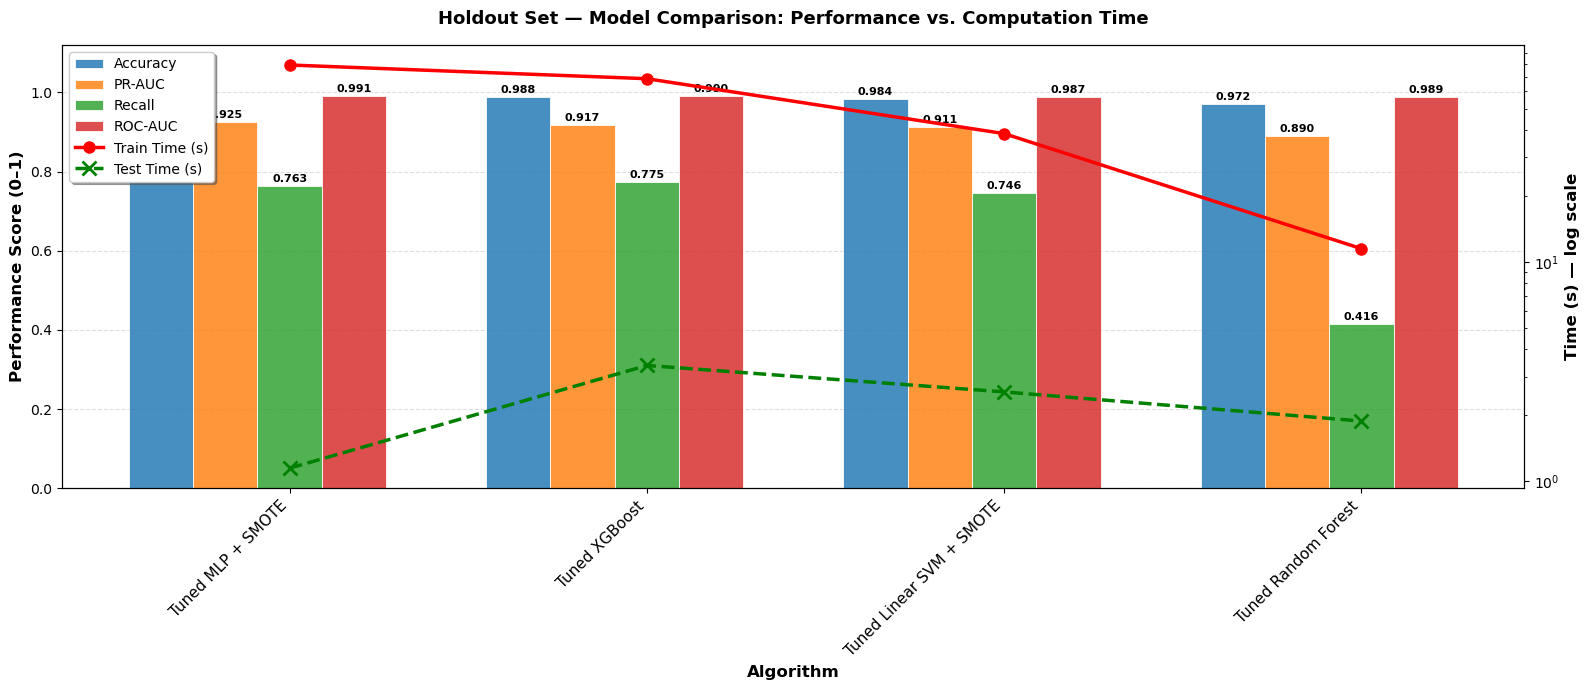

In [131]:
visualize_metrics_graph(test_df, 'final_tuned_models')

Selected final model: Tuned MLP + SMOTE


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


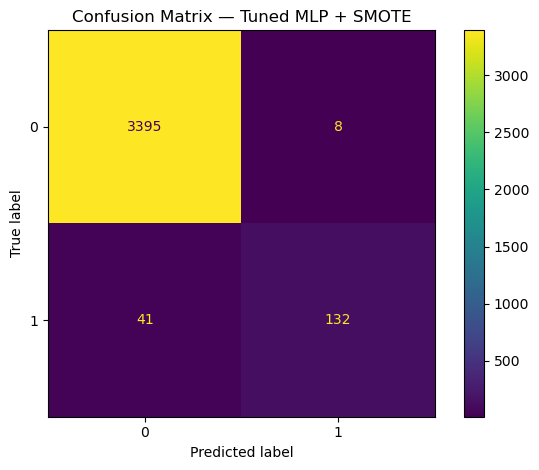

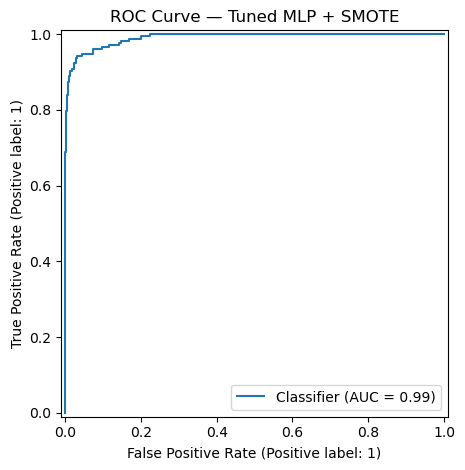

In [132]:
final_model_name = test_df.loc[0, "model"]
final_base_name = final_model_name.replace("Tuned ", "")
final_model = best_models[final_base_name]

print("Selected final model:", final_model_name)

final_pred = final_model.predict(X_test)
final_proba = final_model.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, values_format="d")
plt.title(f"Confusion Matrix — {final_model_name}")
plt.tight_layout()
plt.savefig('images/final_model_confusion_matrix.png')
plt.show()

RocCurveDisplay.from_predictions(y_test, final_proba)
plt.title(f"ROC Curve — {final_model_name}")
plt.tight_layout()
plt.savefig('images/final_model_roc_auc_curve.png')
plt.show()

### Section 12: Feature Importances

Given the model coefficients, attain the list of features that strongly indicated fraudulency.

In [141]:
# ── Helper: get feature names after preprocessing ─────────────────────────────
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocess']
    try:
        return preprocessor.get_feature_names_out()
    except AttributeError:
        return X_train.columns.tolist()

# ── 1. Linear SVM — coefficients via CalibratedClassifierCV ──────────────────
svm_pipeline  = best_models["Linear SVM + SMOTE"]
feature_names = get_feature_names(svm_pipeline)

# CalibratedClassifierCV wraps LinearSVC — coefficients live in calibrated_classifiers_
base_clf      = svm_pipeline.named_steps["model"]           # CalibratedClassifierCV
inner_svc     = base_clf.calibrated_classifiers_[0].estimator  # LinearSVC

if inner_svc.coef_.shape[0] == 1:                           # binary
    coef_values = inner_svc.coef_[0]
else:                                                        # multiclass — average abs coef
    coef_values = np.mean(np.abs(inner_svc.coef_), axis=0)

coef_svm_df = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": coef_values
}).sort_values(by="coefficient", key=np.abs, ascending=False).reset_index(drop=True)

print("\nCoefficients from Linear SVM:")
display(coef_svm_df.head(15))

# ── 2. Random Forest — native feature importances ────────────────────────────
rf_pipeline   = best_models["Random Forest"]
rf_model      = rf_pipeline.named_steps["model"]
feature_names = get_feature_names(rf_pipeline)

feature_importance_rf_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\nFeature Importances from Random Forest:")
display(feature_importance_rf_df.head(15))

# ── 3. XGBoost — native feature importances (gain) ───────────────────────────
xgb_pipeline  = best_models["XGBoost"]
xgb_model     = xgb_pipeline.named_steps["model"]
feature_names = get_feature_names(xgb_pipeline)

feature_importance_xgb_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": xgb_model.feature_importances_            # default: 'weight'; gain available via get_booster()
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\nFeature Importances from XGBoost:")
display(feature_importance_xgb_df.head(15))

# ── 4. MLP — permutation importance (no native coef interpretation) ───────────
mlp_pipeline  = best_models["MLP + SMOTE"]
X_test_mlp    = get_X_for_model("MLP + SMOTE", split="test")

result_mlp = permutation_importance(
    mlp_pipeline, X_test_mlp, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="average_precision"
)

# Permutation importance shuffles pipeline *inputs* — use raw column names
perm_importances_mlp_df = pd.DataFrame({
    "feature":    X_test_mlp.columns.tolist(),              # ← raw features, not preprocessed
    "importance": result_mlp.importances_mean,
    "std":        result_mlp.importances_std
}).sort_values(by="importance", ascending=False).reset_index(drop=True)

print("\nPermutation Importances from MLP:")
display(perm_importances_mlp_df.head(15))


Coefficients from Linear SVM:


,feature,coefficient
0,tfidf_text__link,2.180746
1,tfidf_text__company_profile,1.997520
2,cat__department_Information Technology,1.748548
3,tfidf_text__aptitude,1.572233
4,tfidf_text__american,1.564183
5,tfidf_text__supply,1.411616
6,cat__department_biotech,1.353881
7,tfidf_text__money,1.340044
8,tfidf_text__ohio,1.257117
9,tfidf_text__break,1.240880



Feature Importances from Random Forest:


,feature,importance
0,tfidf_text__company_profile,0.021495
1,num__company_profile_len,0.017385
2,num__company_profile_wc,0.014745
3,tfidf_text__unknown,0.010981
4,tfidf_text__value,0.008813
5,tfidf_text__team,0.007622
6,tfidf_text__growing,0.006201
7,num__description_len,0.006116
8,num__description_wc,0.005440
9,tfidf_text__benefits,0.005420



Feature Importances from XGBoost:


,feature,importance
0,num__company_profile_len,0.028933
1,tfidf_text__000,0.028304
2,tfidf_title__division,0.014424
3,cat__required_education_High School or equivalent,0.012956
4,tfidf_title__tester,0.012059
5,tfidf_text__hiring,0.011928
6,cat__department_CALLCENTER TECH,0.011416
7,cat__industry_Biotechnology,0.009978
8,tfidf_text__different,0.009933
9,cat__required_experience_Internship,0.009096


/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/anaconda3/envs/tf_env/lib/pytho


Permutation Importances from MLP:


,feature,importance,std
0,text,0.597703,0.022663
1,title,0.066080,0.005988
2,industry,0.027745,0.005261
3,department,0.017614,0.003540
4,function,0.009667,0.001984
5,company_profile_wc,0.008497,0.004074
6,required_education,0.005092,0.002827
7,description_wc,0.003132,0.000957
8,company_profile_len,0.002960,0.003797
9,required_experience,0.002747,0.001470


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("Feature Importances across Tuned Models", fontsize=16, fontweight="bold", y=1.01)

# ── Shared style config ───────────────────────────────────────────────────────
TOP_N   = 15
configs = [
    {
        "ax":      axes[0, 0],
        "df":      coef_svm_df.head(TOP_N),
        "x_col":   "coefficient",
        "label":   "Linear SVM — Coefficients (|coef|)",
        "color":   "steelblue",
        "abs":     True,                                    # SVM coefs can be negative
    },
    {
        "ax":      axes[0, 1],
        "df":      feature_importance_rf_df.head(TOP_N),
        "x_col":   "importance",
        "label":   "Random Forest — Feature Importance",
        "color":   "seagreen",
        "abs":     False,
    },
    {
        "ax":      axes[1, 0],
        "df":      feature_importance_xgb_df.head(TOP_N),
        "x_col":   "importance",
        "label":   "XGBoost — Feature Importance",
        "color":   "darkorange",
        "abs":     False,
    },
    {
        "ax":      axes[1, 1],
        "df":      perm_importances_mlp_df.head(TOP_N),
        "x_col":   "importance",
        "label":   "MLP — Permutation Importance",
        "color":   "mediumpurple",
        "abs":     False,
        "std_col": "std",                                   # MLP has std — draw error bars
    },
]

for cfg in configs:
    ax     = cfg["ax"]
    df     = cfg["df"].copy()
    x_col  = cfg["x_col"]
    values = df[x_col].abs() if cfg.get("abs") else df[x_col]

    # Sort descending for clean horizontal bar layout
    df     = df.assign(_val=values).sort_values("_val", ascending=True)
    values = df["_val"]

    xerr = df[cfg["std_col"]] if "std_col" in cfg else None

    ax.barh(
        df["feature"], values,
        xerr=xerr,
        color=cfg["color"],
        alpha=0.75,
        edgecolor="white",
        linewidth=0.5,
        error_kw={"elinewidth": 0.8, "ecolor": "grey", "capsize": 2}
    )

    ax.set_title(cfg["label"], fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Importance / |Coefficient|", fontsize=10)
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    ax.axvline(0, color="black", linewidth=0.6, linestyle="--")

plt.tight_layout()
plt.savefig("images/feature_importance_tuned_models.png", dpi=150, bbox_inches="tight")
plt.show()

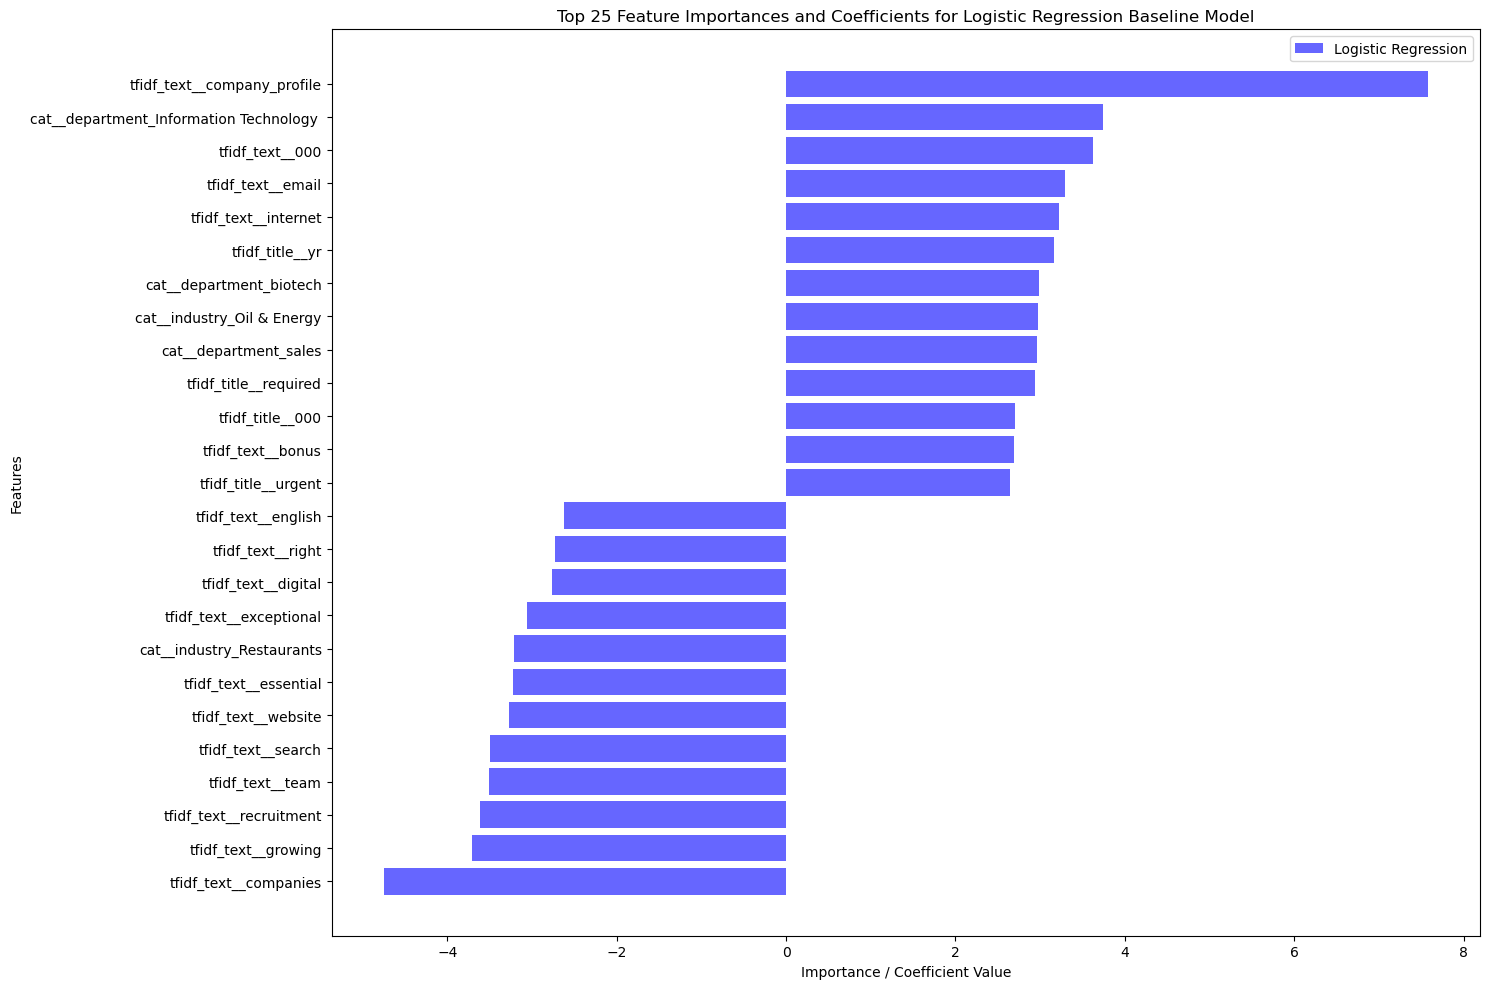

In [ ]:
top25_df = importance_df.reindex(importance_df['coefficient'].abs().sort_values(ascending=False).index).head(25).sort_values('coefficient')  # sort for clean horizontal bar display

plt.figure(figsize=(15, 10))
plt.barh(top25_df['feature'], top25_df['coefficient'], color='blue', alpha=0.6, label='Logistic Regression')

plt.xlabel('Importance / Coefficient Value')
plt.ylabel('Features')
plt.title('Top 25 Feature Importances and Coefficients for Logistic Regression Baseline Model')
plt.legend()
plt.tight_layout()
plt.savefig('images/feature_importances_and_coefficients_baseline.png')
plt.show()

### Section 13: Key Findings

By using SMOTE to balance the ratio of legitimate to fraudulent job postings to 1:1, the Logistic Regression model performed decently, with an ROC AUC score of ~0.8591 and an F1 score of ~0.7125.

The feature importances graph furthermore indicates the following:
- Information Technology increases the chance of fraudulency, which falls in line with my own personal experience of encountering various fraudulent opportunities. Words, like internet, engineering, computer networking, seem to validate this.
- Sales and Research, Oil & Energy, Product Development, Engineering also indicate positive coefficients for fraudulency. Could Smote's oversampling of the fraudulent class also increased the number of these occurrences?
- "Achieve" in a job description could be a key word fraudulent job postings use to mimic legitimate postings.
- Any mentions of team, website, growing (however close this is to 'achieve') affected the coefficients towards legitimacy, perhaps due to sharper specificity of company lingo.
- "Level" may suggest that indication of seniority in a job posting correlates more with legitimate job postings.

### Section 14: Next Steps

Per next steps of this project, consider threshold tuning for the Logistic Regression Model so it can more aggressively identify fraudulent job postings, with a cost of moderate increase in false positives. 

Other models like XGBoost could capture non-linear feature interactions better than the former, and pre-trained models like BERT could contextualize 
encouraging buzz word language often used in fraudulent job postings. 

This model could also benefit from feature enrichment through two datasets:
- The [UCI SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection), which could expand the model to other language commonly used in fraud attempts
- the [Linkedin Job Postings Dataset](https://huggingface.co/datasets/datastax/linkedin_job_listings), while unclassified for legitimate vs. fraudulent job descriptions, could contextualize the model with structured and text features that could complement the EMSCAD schema